In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("data_test.csv", sep=";")
df.head()


,CLIENT_ID,VALUE_DAY,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT
0,3596869440,30.09.2021,18.0,8.0,9.0
1,181778433,30.09.2021,7.0,3.0,3.0
2,4271531990,30.09.2021,2.0,0.0,0.0
3,3949165697,30.09.2021,15.0,4.0,5.0
4,1926920317,30.09.2021,3.0,0.0,0.0


In [3]:
df.info()
print(df.OPER_ACTIVE_30_CNT.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805821 entries, 0 to 805820
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CLIENT_ID           805821 non-null  int64  
 1   VALUE_DAY           805821 non-null  object 
 2   DIGITAL_30_CNT      711169 non-null  float64
 3   TRAN_ACTIVE_30_CNT  711169 non-null  float64
 4   OPER_ACTIVE_30_CNT  711169 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 30.7+ MB
94652


Увидел, что NAN нет, а даты можно привести к датам

In [4]:
df["VALUE_DAY"] = pd.to_datetime(df["VALUE_DAY"], format="%d.%m.%Y")

Построй визуальное представление удержания клиентов в статусе:
- активных клиентов банка (наличие строки для клиента на отчетную дату); 
- диджитал активных (активных в мобильном приложении: наличие хотя бы одного входа);
- операционно активных;
- транзакционно активных;


In [5]:
# бинарные признаки

df["is_active"] = 1

df["is_digital"] = (df["DIGITAL_30_CNT"] > 0).astype(int)

df["is_oper"] = (df["OPER_ACTIVE_30_CNT"] > 0).astype(int)

df["is_tran"] = (df["TRAN_ACTIVE_30_CNT"] > 0).astype(int)

In [ ]:

first_month = df.groupby("CLIENT_ID")["VALUE_DAY"].min().reset_index()
first_month.columns = ["CLIENT_ID", "cohort_month"]

df = df.merge(first_month, on="CLIENT_ID")

# номер мес от когорты

df["cohort_index"] = (
    (df["VALUE_DAY"].dt.year - df["cohort_month"].dt.year) * 12 +
    (df["VALUE_DAY"].dt.month - df["cohort_month"].dt.month)

)

In [7]:
# расчет retention
def get_retention(df, flag):

    cohort = (
        df.groupby(["cohort_month", "cohort_index"])
        .agg({flag: "sum", "CLIENT_ID": "nunique"})
        .rename(columns={"CLIENT_ID": "total_users"})
        .reset_index())

    cohort_pivot = cohort.pivot(
        index="cohort_month",
        columns="cohort_index",
        values=flag)

    cohort_size = cohort_pivot.iloc[:, 0]
    retention = cohort_pivot.divide(cohort_size, axis=0)
    return retention

In [8]:
# считаем retention

ret_active = get_retention(df, "is_active")
ret_digital = get_retention(df, "is_digital")
ret_oper = get_retention(df, "is_oper")
ret_tran = get_retention(df, "is_tran")

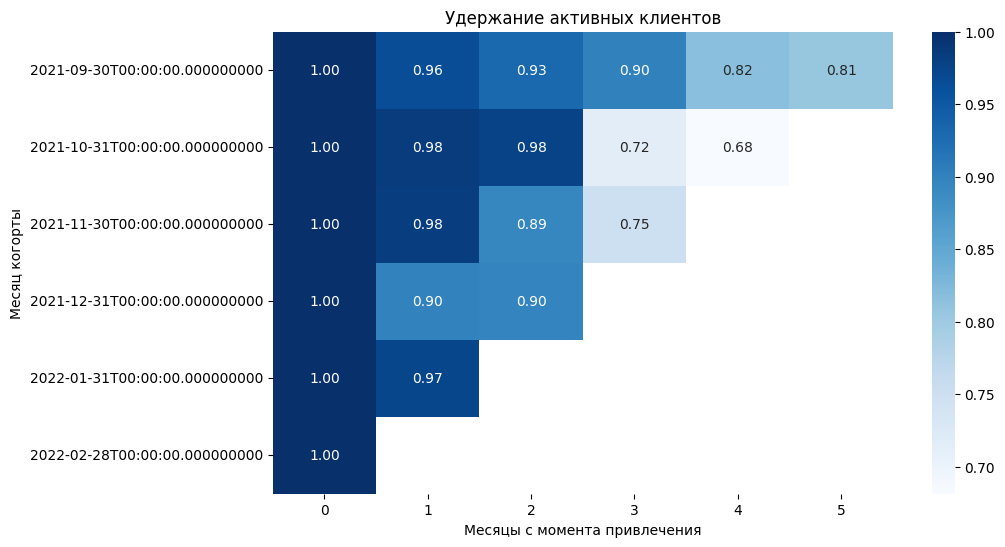

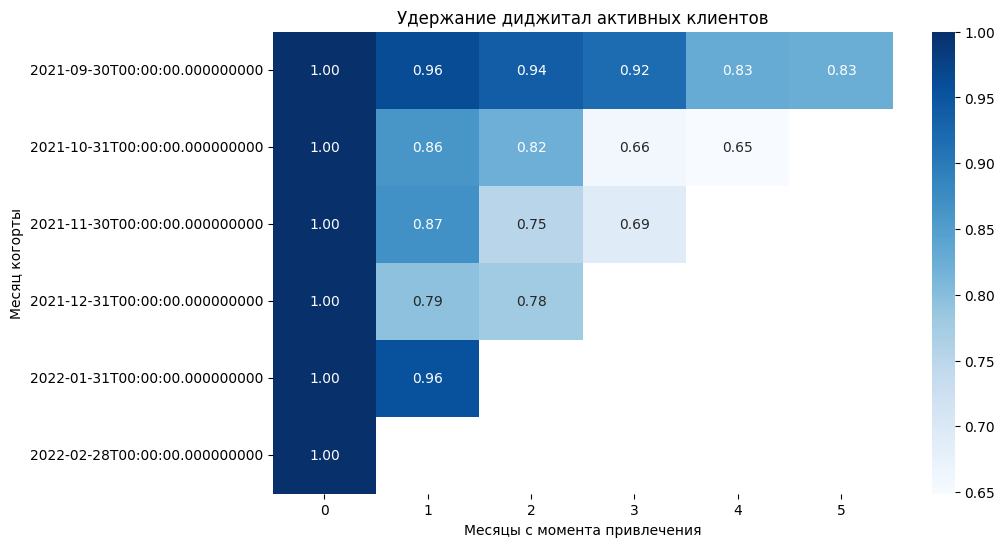

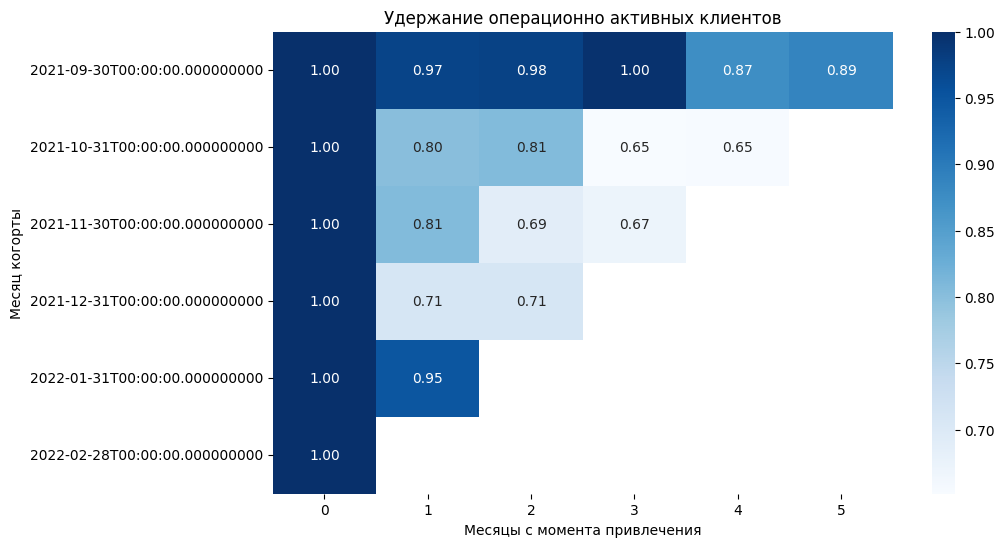

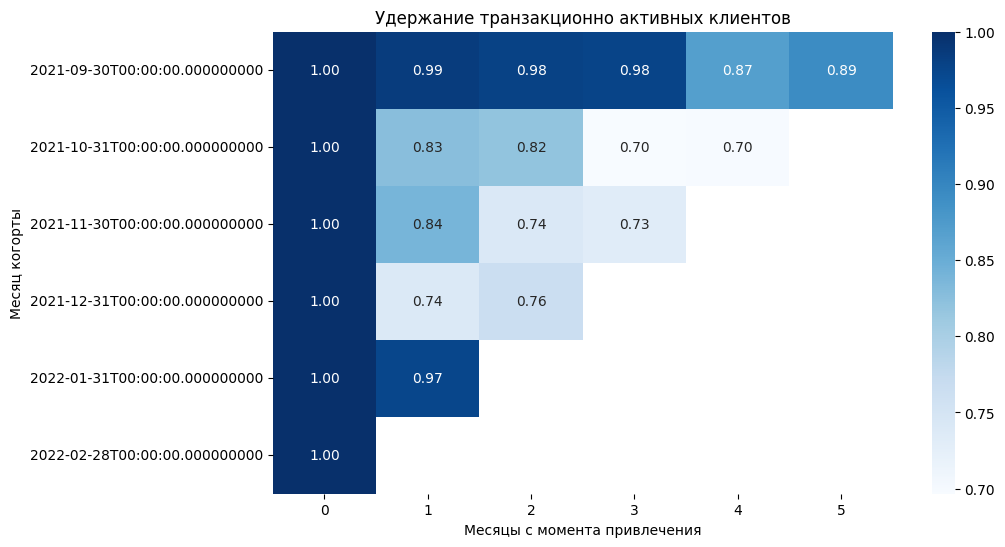

In [13]:
def plot_heatmap(retention, title):
    plt.figure(figsize=(10,6))
    sns.heatmap(retention, annot=True, fmt=".2f", cmap="Blues")
    plt.title(title)
    plt.xlabel("Месяцы с момента привлечения")
    plt.ylabel("Месяц когорты")
    plt.show()

plot_heatmap(ret_active, "Удержание активных клиентов")
plot_heatmap(ret_digital, "Удержание диджитал активных клиентов")
plot_heatmap(ret_oper, "Удержание операционно активных клиентов")
plot_heatmap(ret_tran, "Удержание транзакционно активных клиентов")


In [11]:
df["tran_in_digital"] = np.where(df["is_digital"] == 1,
                                df["is_tran"],
                                np.nan)

penetration = df.groupby("VALUE_DAY")["tran_in_digital"].mean()
print(penetration)


VALUE_DAY
2021-09-30    0.691066
2021-10-31    0.704560
2021-11-30    0.712475
2021-12-31    0.722945
2022-01-31    0.716281
2022-02-28    0.737392
Name: tran_in_digital, dtype: float64


69–73% digital-пользователей совершают транзакции

Проверка частота входов

In [14]:
df.groupby("is_oper")["DIGITAL_30_CNT"].mean()


is_oper
0     4.199510
1    13.598693
Name: DIGITAL_30_CNT, dtype: float64

чем чаще пользователь заходит, тем выше шанс, что он сделает операцию

Зашел, а зачем зашел?

In [17]:
conversion = df[df["is_digital"] == 1]["is_oper"].mean()
conversion

np.float64(0.7852017627162651)